В данной версии ноутбука использовалась другая модель, более маленькая: SmolVLM-256M-Instruct.  
И из-за размера модели метрика на zero-shot оказалась выше чем в любой другой конфигурации.

### Initial actions

In [1]:
import os
from huggingface_hub import login
from tqdm.notebook import tqdm

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForImageTextToText
from transformers.image_utils import load_image
import random

W0324 21:19:52.842000 11872 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
seed_value = 42
rng = np.random.default_rng(seed_value)
random.seed(seed_value)

In [4]:
assert torch.cuda.is_available(), "CUDA is not available, but required!"

In [5]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

### First load and test VLM model

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
model = AutoModelForImageTextToText.from_pretrained(
    "HuggingFaceTB/SmolVLM-256M-Instruct",
    dtype=torch.bfloat16
).to(DEVICE)

def generate_text(images, raw_prompt, model=model, processor=processor):
  # Prepare inputs
  prompt = processor.apply_chat_template(raw_prompt, add_generation_prompt=True)
  inputs = processor(text=prompt, images=images, return_tensors="pt")
  inputs = inputs.to(DEVICE)

  # Generate outputs
  generated_ids = model.generate(**inputs, max_new_tokens=500)
  generated_texts = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )

  return generated_texts[0]

image = load_image("https://cdn.britannica.com/61/93061-050-99147DCE/Statue-of-Liberty-Island-New-York-Bay.jpg")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Can you describe this image?"}
        ]
    },
]

generate_text([image], messages)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

"User:\n\n\n\nCan you describe this image?\nAssistant: The image depicts a large, historic statue of liberty, located in New York City. The statue is a green, cylindrical structure with a human figure atop it. The figure is wearing a flowing gown, and the statue is mounted on a pedestal that is supported by a cylindrical structure. The pedestal is supported by a series of columns, which are visible in the image.\n\nIn the background, there is a large cityscape with numerous skyscrapers and high-rise buildings. The sky is clear, with a gradient of colors transitioning from a pale blue at the top to a deeper blue at the bottom. The buildings are mostly made of glass and steel, and they vary in height and design.\n\nThere are trees and a small body of water in the foreground, which appears to be a river or a lake. The water is calm, and the reflection of the sky and buildings can be seen on the surface.\n\nThe statue is situated on a small island or peninsula, which is surrounded by a lar

### Load datasets

In [7]:
from datasets import load_dataset

train_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="train")
val_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="validation")
test_dataset_linxy = load_dataset("linxy/LaTeX_OCR", name="human_handwrite", split="test")

### Test model

In [8]:
from IPython.display import display, Math

In [9]:
image = test_dataset_linxy[2]['image']

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Convert this handwritten formula to LaTeX"}
        ]
    },
]

answer = generate_text(image, messages)
print(answer)
print('-----------------------------------')
print('Example: ')
print(test_dataset_linxy[2]['text'])

User:


Convert this handwritten formula to LaTeX
Assistant: \frac{2tan\alpha}{1-tan^{\alpha}\alpha}
-----------------------------------
Example: 
\frac { 2 \tan \alpha } { 1 - \tan ^ { 2 } \alpha }


In [10]:
display(Math(test_dataset_linxy[2]['text']))

<IPython.core.display.Math object>

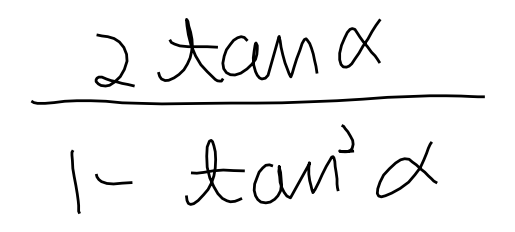

In [11]:
image

In [12]:
substring = 'Assistant: '
index = answer.find(substring)
if index != -1:
  display(Math(answer[index+len(substring):]))

<IPython.core.display.Math object>

### Calculate metrics for zero-shot inference

In [13]:
answer[index+len(substring):]

'\\frac{2tan\\alpha}{1-tan^{\\alpha}\\alpha}'

In [14]:
from rouge_score import rouge_scorer
import sacrebleu
import jiwer
from tqdm.notebook import tqdm

In [15]:
def evaluate_model(test_dataset, scoring='cer', examples=None, mode='_0shot', model=model, processor=processor):
  scores = []
  loop = tqdm(test_dataset, desc=f"Processing {mode}", leave=True)

  # prepare prompt for the model
  base_prompt_text = "Write the LaTeX representation for this image."
  if mode == '_0shot':
    prompt = [
      { "role": "user",
        "content" : [
        {"type" : "text",  "text" : base_prompt_text},
        {"type" : "image"} ]
      }
    ]
  elif mode == '_1shot':
    if examples is None:
      raise ValueError("Для one-shot нужен examples для выбора примера!")

    example_item = examples[0]
    example_image = example_item['image']
    example_text = example_item['text'].replace(" ", "")

    prompt = [
      {
        "role": "user",
        "content": [
            {"type": "text", "text": base_prompt_text},
            {"type": "image"}
        ]
      },
      {
        "role": "assistant",
        "content": [
            {"type": "text", "text": example_text}
        ]
      },
      {
        "role": "user",
        "content": [
            {"type": "text", "text": base_prompt_text}, 
            {"type": "image"}
        ]
      }
    ]
  else:
    raise ValueError("Неизвестный mode! Используйте '_0shot' или '_1shot'")

  # loop for calculating metric
  for item in loop:
    image = item['image']
    text = item['text'].replace(" ", "")

    if mode == '_0shot':
      answer = generate_text([image], prompt, model, processor)
    elif mode == '_1shot':
      answer = generate_text([example_image, image], prompt, model, processor)

    substring = 'Assistant: '
    index = answer.rfind(substring)
    if index == -1:
      index = 0
    prediction = answer[index+len(substring):]
    reference = text


    # Initialize and calculate scores
    score = 0
    if scoring == 'rouge':
      rogueL = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
      rogueL_scores = rogueL.score(prediction, reference)
      score = rogueL_scores['rougeL'][2]
    elif scoring == 'bleu':
      prediction = [prediction]
      reference = [[reference]]
      bleu = sacrebleu.corpus_bleu(prediction, reference)
      score = bleu.score
    elif scoring == 'cer':
      score = jiwer.cer(reference, prediction)
    else:
      raise ValueError('Error: Unknown type of score')
    scores.append(score)
    # print("REFERENCE: ", reference)
    # display(Math(reference))
    # print()
    # print("PREDICTION: ", prediction)
    # display(Math(prediction))
    # print(score)
  scores = np.array(scores)
  return scores.mean()

In [16]:
# zero_shot_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
zero_shot_metrics = {'cer': 0.}
for metric in zero_shot_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, scoring=metric, mode='_0shot')
  zero_shot_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing _0shot:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.18458643107236367
-----------------------------------------


zero-shot inference: cer = 0.18458643107236367

### Calculate metrics for one-shot inference

In [17]:
# @title
train_examples = [train_dataset_linxy[0]]
# one_shot_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
one_shot_metrics = {'cer': 0.}
for metric in one_shot_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, scoring=metric, examples=train_examples, mode='_1shot')
  one_shot_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing _1shot:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.19897172821880035
-----------------------------------------


one-shot inference: cer = 0.19897172821880035

### Supervised fine-tuning (SFT) using linxy/LaTeX_OCR:train

#### Small VLM (SmolVLM-256M-Instruct)

In [18]:
import gc

gc.collect()
torch.cuda.empty_cache() 
torch.cuda.reset_peak_memory_stats()

In [19]:
from unsloth import FastVisionModel

model_id = "HuggingFaceTB/SmolVLM-256M-Instruct"

baseline_model, baseline_tokenizer = FastVisionModel.from_pretrained(
    model_id,
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11872\2918108205.py:1: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastVisionModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.10: Fast Idefics3 patching. Transformers: 5.3.0.
   \\   /|    NVIDIA GeForce RTX 3070 Laptop GPU. Num GPUs = 1. Max memory: 8.0 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.10.0+cu130. CUDA: 8.6. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

In [20]:
instruction = "Write the LaTeX representation for this image."

# Форматируем под chat-шаблон
def convert_to_conversation(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["text"]} ]
        },
    ]
    return { "messages" : conversation }

train_ds1 = train_dataset_linxy.map(convert_to_conversation, remove_columns=train_dataset_linxy.column_names)
eval_ds1 = val_dataset_linxy.map(convert_to_conversation, remove_columns=val_dataset_linxy.column_names)
test_ds1 = test_dataset_linxy.map(convert_to_conversation, remove_columns=test_dataset_linxy.column_names)

In [21]:
train_ds1[0]

{'messages': [{'content': [{'image': None,
     'text': 'Write the LaTeX representation for this image.',
     'type': 'text'},
    {'image': {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x03\x00\x00\x00G\x08\x06\x00\x00\x00\x9a\x8dD\x04\x00\x00\x16\xa4IDATx\x9c\xed\x9d\x07\x94\xd4T\x1b\x86/K\x95\xde{\x11\xe4\xacH\x11\x90^T\xba\x14]@\xaa\xc0J\x11\x90\xa2\x804\x11\x10D`\xe9M)"\xc8\xd2\xa5\xad\xc8\x02\xd2\x11\x14\x04\x0f\x08, E\xdaAzo\x0b\xb8,\x90\xff\xbc\xd7\xff\xc6$\x93\x99\x9d\xd9\xc9$\x99\xcd\xf7\x9c\x13\x98\x9d\xc9$\x99\x94{\xbf\xfb\x95\xf7&\x93$Ib\x04A\x10\x04A8\x96\x10\xab\x0f\x80 \x08\x82 \x08k!c\x80 \x08\x82 \x1c\x0e\x19\x03\x04A\x10\x04\xe1p\xc8\x18 \x08\x82 \x08\x87C\xc6\x00A\x10\x04A8\x1c2\x06\x08\x82 \x08\xc2\xe1\x901@\x10\x04A\x10\x0e\x87\x8c\x01\x82 \x08\x82p8d\x0c\x10\x04A\x10\x84\xc3!c\x80 \x08\x82 \x0cd\xe7\xce\x9dl\xd0\xa0A,&&\x86\x05\x0b\xc9H\x8e\x98 \x08\x82 \x8c\x01\n\xff\xb9s\xe7f\xd7\xaf_\xe7\x7fGEE\xb1w\xdf}\x97\xd9\x1d\xf2\x0c\x10\x04A\x10\x84A$K\x

In [22]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

In [23]:
import copy

model = copy.deepcopy(baseline_model)
tokenizer = copy.deepcopy(baseline_tokenizer)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True, 
    r = 16, # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16, # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.vision_model.encoder` require gradients


In [24]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_ds1,
    eval_dataset = eval_ds1,

    # compute_metrics = compute_metrics,
    # preprocess_logits_for_metrics = preprocess_logits_for_metrics,

    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = np.ceil(0.1*30),
        max_steps = 30,
        num_train_epochs = 1,
        learning_rate = 1e-5,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",

        eval_strategy = "steps",
        eval_steps = 10,
        logging_steps = 10,
        eval_on_start = True,

        # load_best_model_at_end=True,
        # metric_for_best_model="cer",
        # greater_is_better=False,

        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

In [25]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA GeForce RTX 3070 Laptop GPU. Max memory = 8.0 GB.
1.006 GB of memory reserved.


In [26]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,200 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 7,538,688 of 264,023,616 (2.86% trained)
Unsloth: Not an error, but Idefics3ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Step,Training Loss,Validation Loss
0,No log,3.698383
10,3.721093,3.602816
20,3.717197,3.497389
30,3.569475,3.432411


Unsloth: Will smartly offload gradients to save VRAM!


In [27]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

315.3616 seconds used for training.
5.26 minutes used for training.
Peak reserved memory = 5.725 GB.
Peak reserved memory for training = 4.719 GB.
Peak reserved memory % of max memory = 71.562 %.
Peak reserved memory for training % of max memory = 58.988 %.


In [28]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

In [29]:
FastVisionModel.for_inference(model) # Enable for inference!

image = test_dataset_linxy[2]["image"]
instruction = "Write the LaTeX representation for this image."

messages = [
    {"role": "user", "content": [
        {"type": "image"},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
generated_ids = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

 \frac{2tan\alpha}{1-tan^{\alpha}}<end_of_utterance>


In [30]:
generated_texts = tokenizer.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )
answer = generated_texts[0]
answer

'User:\n\n\nWrite the LaTeX representation for this image.\nAssistant: \\frac{2tan\\alpha}{1-tan^{\\alpha}}'

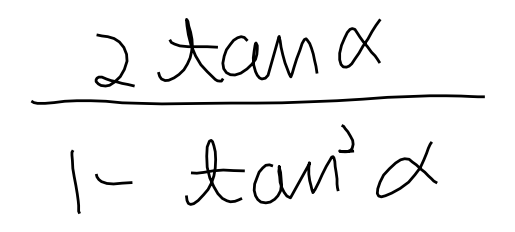

In [31]:
image

In [32]:
display(Math(test_dataset_linxy[2]['text']))

<IPython.core.display.Math object>

In [33]:
substring = 'Assistant: '
index = answer.find(substring)
if index != -1:
  display(Math(answer[index+len(substring):]))

<IPython.core.display.Math object>

#### Calculate metrics for SFT model (linxy dataset)

In [34]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def generate_text(images, raw_prompt, model, processor):
  # Prepare inputs
  prompt = processor.apply_chat_template(raw_prompt, add_generation_prompt=True)
  inputs = processor(text=prompt, images=images, add_special_tokens = False, return_tensors="pt")
  inputs = inputs.to(DEVICE)

  # Generate outputs
  generated_ids = model.generate(**inputs, use_cache = True, temperature = 1.5, min_p = 0.1, max_new_tokens=500)
  generated_texts = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )

  return generated_texts[0]

def evaluate_model(test_dataset, model, processor, scoring='cer'):
  scores = []
  loop = tqdm(test_dataset, desc=f"Processing...", leave=True)

  # prepare prompt for the model
  instruction = "Write the LaTeX representation for this image."

  prompt = [
      { "role": "user",
        "content" : [
          {"type" : "text",  "text"  : instruction},
          {"type" : "image"} ]
      }
  ]
  
  # loop for calculating metric
  for item in loop:
    image = item['image']
    text = item['text'].replace(" ", "")

    answer = generate_text([image], prompt, model, processor)

    substring = 'Assistant: '
    index = answer.rfind(substring)
    if index == -1:
      index = 0
    prediction = answer[index+len(substring):]
    reference = text

    # Initialize and calculate scores
    score = 0
    if scoring == 'rouge':
      rogueL = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
      rogueL_scores = rogueL.score(prediction, reference)
      score = rogueL_scores['rougeL'][2]
    elif scoring == 'bleu':
      prediction = [prediction]
      reference = [[reference]]
      bleu = sacrebleu.corpus_bleu(prediction, reference)
      score = bleu.score
    elif scoring == 'cer':
      score = jiwer.cer(reference, prediction)
    else:
      raise ValueError('Error: Unknown type of score')
    scores.append(score)
    # print("REFERENCE: ", reference)
    # display(Math(reference))
    # print()
    # print("PREDICTION: ", prediction)
    # display(Math(prediction))
    # print(score)
  scores = np.array(scores)
  return scores.mean()

In [35]:
model.save_pretrained_merged("Azaper/SmolVLM-256M-SFT-linxy", tokenizer)
# model.push_to_hub_merged("Azaper/SmolVLM-256M-SFT-linxy", tokenizer)

Found HuggingFace hub cache directory: E:\MyScripts_heavy\Hugging_face_models\hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `Azaper/SmolVLM-256M-SFT-linxy`: 100%|██████████| 1/1 [00:00<00:00,  5.05it/s]


Successfully copied all 1 files from cache to `Azaper/SmolVLM-256M-SFT-linxy`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]


Unsloth: Merge process complete. Saved to `e:\MyScripts_heavy\vlm-handwriting-to-latex\notebooks\Azaper\SmolVLM-256M-SFT-linxy`


In [50]:
tokenizer = AutoProcessor.from_pretrained("Azaper/SmolVLM-256M-SFT-linxy")
model = AutoModelForImageTextToText.from_pretrained(
    "Azaper/SmolVLM-256M-SFT-linxy",
    dtype=torch.bfloat16
).to(DEVICE)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

In [37]:
# @title
# SFT1_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
SFT1_metrics = {'cer': 0.}
for metric in SFT1_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, model=model, processor=tokenizer, scoring=metric)
  SFT1_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing...:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.18811789566765802
-----------------------------------------


baseline: 0.175  
lr = 1e-5, max_steps = 30, lora_alpha = 16, weight_decay = 0.01, r = 16: cer = 0.17845174118011006!  
lr = 1e-5, max_steps = 60, lora_alpha = 16, weight_decay = 0.01, r = 16: cer = 0.18568867279886783  
lr = 1e-5, max_steps = 30, lora_alpha = 8, weight_decay = 0.01, r = 16: cer = 0.17930071693299796  
lr = 1e-5, max_steps = 60, lora_alpha = 16, weight_decay = 0.1, r = 16: cer = 0.18662034981750136  
lr = 1e-5, max_steps = 30, lora_alpha = 4, weight_decay = 0.01, r = 4: cer = 0.1808052762035147  
lr = 1e-4, max_steps = 30, lora_alpha = 4, weight_decay = 0.01, r = 4: cer = 0.1921778698911015  
lr = 1e-4, max_steps = 30, lora_alpha = 1, weight_decay = 0.01, r = 1: cer = 0.18393806336855992  

finetune_vision_layers = True, finetune_language_layers = False, 
finetune_attention_modules = False, finetune_mlp_modules = True, 
lr = 1e-4, max_steps = 30, lora_alpha = 16, weight_decay = 0.01, r = 16: cer = 0.7626815946061651  

finetune_vision_layers = True, finetune_language_layers = False, 
finetune_attention_modules = False, finetune_mlp_modules = True, 
lr = 1e-5, max_steps = 30, lora_alpha = 16, weight_decay = 0.01, r = 16: cer = 0.18070323538718813  

Лучшая конфигурация: lr = 1e-5, max_steps = 30, lora_alpha = 16, weight_decay = 0.01, r = 16: cer = 0.17845174118011006  
Обновлённое значение метрики с изменённым промптом: cer = 0.18811789566765802

### SFT model on 2 datasets (linxy + deepcopy)

In [38]:
train_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="train")
val_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="val")
test_dataset_deepcopy = load_dataset("deepcopy/MathWriting-human", split="test")

In [39]:
def convert_to_conversation_deepcopy(sample):
    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : instruction},
            {"type" : "image", "image" : sample["image"]} ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : sample["latex"]} ]
        },
    ]
    return { "messages" : conversation }

In [40]:
train_ds2 = train_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=train_dataset_deepcopy.column_names)
eval_ds2 = val_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=val_dataset_deepcopy.column_names)
test_ds2 = test_dataset_deepcopy.map(convert_to_conversation_deepcopy, remove_columns=test_dataset_deepcopy.column_names)

In [41]:
from datasets import concatenate_datasets

train_ds2 = concatenate_datasets([train_ds1, train_ds2])
eval_ds2 = concatenate_datasets([eval_ds1, eval_ds2])
test_ds2 = concatenate_datasets([test_ds1, test_ds2])

In [42]:
gc.collect()
torch.cuda.empty_cache() 
torch.cuda.reset_peak_memory_stats()

In [43]:
import copy

model = copy.deepcopy(baseline_model)
tokenizer = copy.deepcopy(baseline_tokenizer)

model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers = True,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True, 
    r = 16, # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16, # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Making `model.base_model.model.model.vision_model.encoder` require gradients


In [44]:
FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_ds2,
    # eval_dataset = eval_ds2,

    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = np.ceil(0.1*30),
        max_steps = 30,
        num_train_epochs = 1,
        learning_rate = 1e-5,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",

        # eval_strategy = "steps",
        # eval_steps = 10,
        logging_steps = 10,
        # eval_on_start = True,

        seed = 3407,
        output_dir = "outputs",
        report_to = "none",     # For Weights and Biases

        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

In [45]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 231,064 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 7,538,688 of 264,023,616 (2.86% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
10,2.928905
20,2.764318
30,2.755875


In [46]:
model.save_pretrained_merged("Azaper/SmolVLM-256M-SFT-linxy-deepcopy", tokenizer)
# model.push_to_hub_merged("Azaper/SmolVLM-256M-SFT-linxy-deepcopy", tokenizer)

Found HuggingFace hub cache directory: E:\MyScripts_heavy\Hugging_face_models\hub
Checking cache directory for required files...


Unsloth: Copying 1 files from cache to `Azaper/SmolVLM-256M-SFT-linxy-deepcopy`: 100%|██████████| 1/1 [00:00<00:00,  3.46it/s]


Successfully copied all 1 files from cache to `Azaper/SmolVLM-256M-SFT-linxy-deepcopy`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:01<00:00,  1.52s/it]


Unsloth: Merge process complete. Saved to `e:\MyScripts_heavy\vlm-handwriting-to-latex\notebooks\Azaper\SmolVLM-256M-SFT-linxy-deepcopy`


In [47]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def generate_text(images, raw_prompt, model, processor):
  # Prepare inputs
  prompt = processor.apply_chat_template(raw_prompt, add_generation_prompt=True)
  inputs = processor(text=prompt, images=images, add_special_tokens = False, return_tensors="pt")
  inputs = inputs.to(DEVICE)

  # Generate outputs
  generated_ids = model.generate(**inputs, use_cache = True, temperature = 1.5, min_p = 0.1, max_new_tokens=500)
  generated_texts = processor.batch_decode(
      generated_ids,
      skip_special_tokens=True,
  )

  return generated_texts[0]

def evaluate_model(test_dataset, model, processor, scoring='cer'):
  scores = []
  loop = tqdm(test_dataset, desc=f"Processing...", leave=True)

  # prepare prompt for the model
  instruction = "Write the LaTeX representation for this image."

  prompt = [
      { "role": "user",
        "content" : [
          {"type" : "text",  "text"  : instruction},
          {"type" : "image"} ]
      }
  ]
  
  # loop for calculating metric
  for item in loop:
    image = item['image']
    text = item['text'].replace(" ", "")

    answer = generate_text([image], prompt, model, processor)

    substring = 'Assistant: '
    index = answer.rfind(substring)
    if index == -1:
      index = 0
    prediction = answer[index+len(substring):]
    reference = text

    # Initialize and calculate scores
    score = 0
    if scoring == 'rouge':
      rogueL = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
      rogueL_scores = rogueL.score(prediction, reference)
      score = rogueL_scores['rougeL'][2]
    elif scoring == 'bleu':
      prediction = [prediction]
      reference = [[reference]]
      bleu = sacrebleu.corpus_bleu(prediction, reference)
      score = bleu.score
    elif scoring == 'cer':
      score = jiwer.cer(reference, prediction)
    else:
      raise ValueError('Error: Unknown type of score')
    scores.append(score)
    # print("REFERENCE: ", reference)
    # display(Math(reference))
    # print()
    # print("PREDICTION: ", prediction)
    # display(Math(prediction))
    # print(score)
  scores = np.array(scores)
  return scores.mean()

In [54]:
tokenizer = AutoProcessor.from_pretrained("Azaper/SmolVLM-256M-SFT-linxy-deepcopy")
model = AutoModelForImageTextToText.from_pretrained(
    "Azaper/SmolVLM-256M-SFT-linxy-deepcopy",
    dtype=torch.bfloat16
).to(DEVICE)

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

In [49]:
# @title
# SFT2_metrics = {'cer': 0., 'bleu': 0., 'rouge': 0.}
SFT2_metrics = {'cer': 0.}
for metric in SFT2_metrics.keys():
  print('Calculating metric: ', metric)
  value = evaluate_model(test_dataset_linxy, model=model, processor=tokenizer, scoring=metric)
  SFT2_metrics[metric] = value
  print(f"{metric} = {value}")
  print('-----------------------------------------')

Calculating metric:  cer


Processing...:   0%|          | 0/70 [00:00<?, ?it/s]

cer = 0.18590918239511497
-----------------------------------------


baseline: 0.175

SFT 2 score (linxy+deepcopy): cer = 0.18590918239511497

### Results

В итоге лучшей моделью (по метрике CER) оказалась базовая версия модели в режиме работы zero-shot. Поэтому в дальнейшем в инференсе и приложении Streamlit будем использовать именно её.